## Cписочные выражения и зачем они нужны

In [ ]:
# представим, что нам нужно создать список
numbers = []
for i in range(5):
    numbers.append(int(input()))
print(numbers)

В Python, помимо стандартных конструкций — цикла for и встроенных функций вроде append() или range(), — есть более лаконичный способ создавать списки

In [ ]:
# а вот как это сделать со списочным выражением
numbers = [int(input()) for i in range(5)]
print(numbers)

Имейте в виду! Списочные выражения часто называют **list comprehension**.

In [ ]:
# как полуить список квадратов натуральных чисел от 1 до 10
squares = [x**2 for x in range(1, 11)]
print(squares)

[1, 4, 9, 16, 25, 36, 49, 64, 81, 100]


### Как добавить условия и вложенные циклы в списочные выражения
Списочные выражения позволяют не только фильтровать значения, но и включать вложенные циклы. Это особенно полезно при работе с матрицами, строками, словарями и другими составными структурами данных.

In [ ]:
matrix = [[int(x) for x in input().split()] for i in range(5)]
print(matrix)

[[], [], [], [], []]


In [ ]:
# как можно добавлять условия
numbers = [int(input()) for i in range(5)]
avg = sum(numbers) // len(numbers)

numbers = [element for element in numbers if element > avg]
print(numbers)

[4, 5, 4]


### Фильтрация словаря
Списочные выражения работают и с парами *ключ — значение*:

In [ ]:
countries = {
    "Россия": ["русский"],
    "Беларусь": ["белорусский", "русский"],
    "Бельгия": ["немецкий", "французский", "нидерландский"],
    "Вьетнам": ["вьетнамский"]
}

In [ ]:
# вернем список стран, в которых больше одного языка
multiple_lang = [country for (country, lang) in countries.items() if len(lang) > 1]
print(multiple_lang)

['Беларусь', 'Бельгия']


In [ ]:
# c помощью словарного включения можно собрать dict из списка:
countries = {country: capital for country, capital in [
    ("Россия", "Москва"),
    ("Беларусь", "Минск"),
    ("Сербия", "Белград")
]}
print(countries)

{'Россия': 'Москва', 'Беларусь': 'Минск', 'Сербия': 'Белград'}


### Полезная функиця map()

In [ ]:
### познакомимся с полезной функцие map()
def root_maker(number: int) -> int:
    return round(number ** 0.5)

square_list = [x ** 2  for x in range(1, 11)]

final_list = list(map(root_maker, square_list))
print(final_list)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


#### Задача 1. Проблемы городского управления

Городское управление анализирует плотность застройки в пяти кварталах (данные — площадь в га и число зданий). Нужно рассчитать плотность (зданий/га), затем округлить все значения до одного знака после запятой. 

В итоге вывести список округлённых плотностей.

In [2]:
# площадь: 5.2 га, зданий: 34
quarters = [
    (5.2, 34),  
    (3.8, 27),
    (6.1, 45),
    (4.5, 19),
    (7.0, 52)
]

unround_density = [quarter[1] / quarter[0] for quarter in quarters]
round_density = list(map(lambda x: round(x, 1), unround_density))
print(round_density)

[6.5, 7.1, 7.4, 4.2, 7.4]


## Генераторы и генераторные выражения
* Генератор — это объект, который сразу при создании не вычисляет значения всех своих элементов.
* Он хранит в памяти только последний вычисленный элемент, правило перехода к следующему и условие, при котором выполнение прерывается.
* Вычисление следующего значения происходит лишь при выполнении метода next(). Предыдущее значение при этом теряется.

Этим генераторы отличаются от списков — те хранят в памяти все свои элементы, и удалить их можно только программно. Вычисления с помощью генераторов называются ленивыми, они экономят память

In [ ]:
# синтаксис генератора
def gen_function(n):
    while n > 0:
        yield n
        n -= 1

In [ ]:
# Вызовем генератор
gen = gen_function(5)

# здесь вызываем функцию next и передаем в нее генератор
print(next(gen))

# здесь вызываем метод __next__ у генератора
print(gen.__next__())

print(next(gen))
print(next(gen))
print(next(gen))

5
4
3
2
1


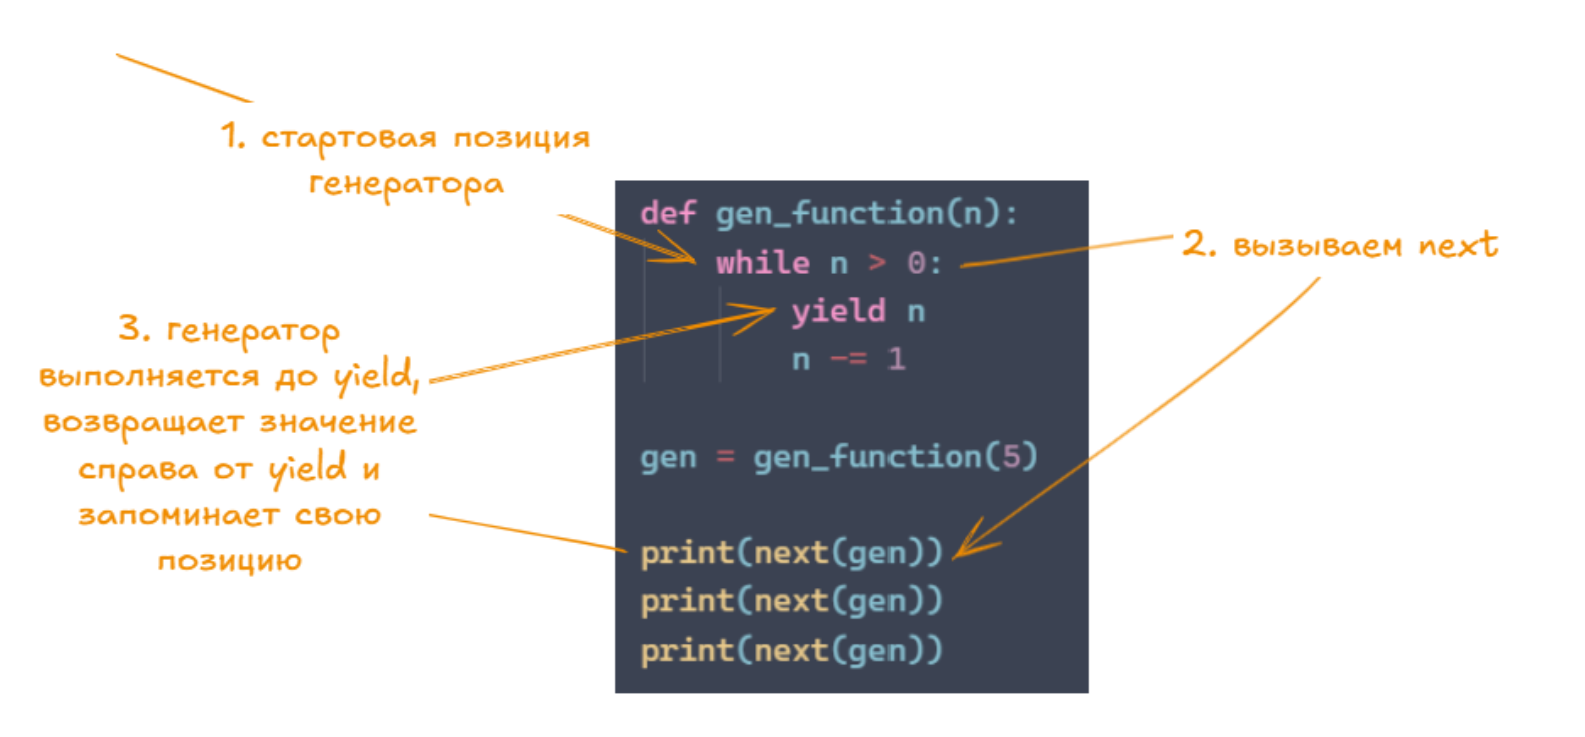

Помимо yield генератор может содержать и return. Встретив return генератор выбрасывает исключение StopIteration, а возвращенное значение записывается в объект StopIteration в атрибут value.

In [ ]:
def gen_function(n):
    while n > 0:
        yield n
        n -= 1
    return 100

gen = gen_function(3)
print(next(gen))
print(next(gen))
print(next(gen))
try:
    print(next(gen))
except StopIteration as e:
    print(e.value)

3
2
1
100


Если мы не будем указывать return, то в атрибуте value исключения StopIteration будет находится значение None.

In [ ]:
def gen_function(n):
    while n > 0:
        yield n
        n -= 1
    # return 100

gen = gen_function(3)
print(next(gen))
print(next(gen))
print(next(gen))
try:
    print(next(gen))
except StopIteration as e:
    print(e.value)

3
2
1
None


У генератора есть метод close при вызове которого выбрасывается исключение GeneratorExit и генератор завершает свою работу. Если после вызова close мы попытаемся получить значение из генератора, то будет выброшено исключение StopIteration.

In [ ]:
def gen_function(n):
    while n > 0:
        yield n
        n -= 1

gen = gen_function(3)

print(next(gen))
gen.close()
print(next(gen))

### Генераторные выражения
Создать генератор можно не только используя генераторную функцию, но и с помощью генераторного выражения.

In [ ]:
gen = (v for v in range(3))
print(f"Type gen is {type(gen)}")

print(next(gen))
print(next(gen))
print(next(gen))

Type gen is <class 'generator'>
0
1
2
